# 01 — Ingestão e qualidade dos dados

**Projeto Integrador IV · Univesp** — Análise de dados públicos da COVID-19

Atende às atividades da Quinzena 3 *"Importar e estruturar o conjunto de dados em ambiente
Python"* (07/09 – 09/09) e *"Avaliar dimensões, tipos de dados, valores ausentes e
duplicidades"* (08/09 – 12/09).

**Fonte:** [Brasil.IO — `caso_full`](https://brasil.io/dataset/covid19/caso_full/), compilado
dos boletins das secretarias estaduais de saúde.

> Antes de rodar, converta o CSV uma única vez: `python -m pi4.ingestao`

In [1]:
import numpy as np
import pandas as pd

from pi4 import CAMINHOS, carregar

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
CAMINHOS.resultados.mkdir(parents=True, exist_ok=True)

df = carregar()          # os dois níveis: municípios e unidades federativas
diagnostico = []         # cada achado vira uma linha da tabela final

f"{len(df):,} linhas x {df.shape[1]} colunas".replace(",", ".")

'3.853.648 linhas x 18 colunas'

## 1. Dimensões, tipos e memória

O Parquet já vem tipado pela ingestão: datas como data, contadores como inteiro de 32 bits,
`state` e `place_type` como categoria. Lido direto do CSV, tudo isso viraria `object` e
ocuparia várias vezes mais memória.

In [2]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3853648 entries, 0 to 3853647
Data columns (total 18 columns):
 #   Column                                         Dtype         
---  ------                                         -----         
 0   city                                           string        
 1   city_ibge_code                                 Int32         
 2   date                                           datetime64[ns]
 3   epidemiological_week                           Int32         
 4   estimated_population                           Int32         
 5   estimated_population_2019                      Int32         
 6   is_last                                        boolean       
 7   is_repeated                                    boolean       
 8   last_available_confirmed                       Int32         
 9   last_available_confirmed_per_100k_inhabitants  Float32       
 10  last_available_date                            datetime64[ns]
 11  last_availa

In [3]:
df.head(3)

,city,city_ibge_code,date,epidemiological_week,estimated_population,estimated_population_2019,is_last,is_repeated,last_available_confirmed,last_available_confirmed_per_100k_inhabitants,last_available_date,last_available_death_rate,last_available_deaths,order_for_place,place_type,state,new_confirmed,new_deaths
0,<NA>,12,2020-03-17,202012,894470,881935,False,False,3,0.33539,2020-03-17,0.0,0,1,state,AC,3,0
1,<NA>,12,2020-03-18,202012,894470,881935,False,False,3,0.33539,2020-03-18,0.0,0,2,state,AC,0,0
2,<NA>,12,2020-03-19,202012,894470,881935,False,False,4,0.44719,2020-03-19,0.0,0,3,state,AC,1,0


## 2. Cobertura temporal e granularidade

Uma linha por local e por dia. A coluna `place_type` separa dois níveis que convivem na
mesma tabela.

In [4]:
inicio, fim = df["date"].min(), df["date"].max()
dias_calendario = (fim - inicio).days + 1

print(f"Período:          {inicio:%d/%m/%Y} a {fim:%d/%m/%Y}  ({dias_calendario} dias)")
print(f"Datas distintas:  {df['date'].nunique()}")
print()
print(df["place_type"].value_counts().to_string())

municipios = df.loc[df["place_type"] == "city", "city_ibge_code"].nunique()
ufs = df["state"].nunique()
print(f"\nMunicípios distintos: {municipios}")
print(f"UFs distintas:        {ufs}")

diagnostico += [
    {"item": "Período coberto", "valor": f"{inicio:%d/%m/%Y} a {fim:%d/%m/%Y}",
     "interpretacao": "Da chegada da doença ao Brasil ao fim da onda Ômicron"},
    {"item": "Total de registros", "valor": f"{len(df):,}".replace(",", "."),
     "interpretacao": "Uma linha por local e por dia"},
    {"item": "Municípios", "valor": municipios,
     "interpretacao": "Praticamente a totalidade dos 5.570 municípios brasileiros"},
    {"item": "Unidades federativas", "valor": ufs,
     "interpretacao": "26 estados e o Distrito Federal"},
]

Período:          25/02/2020 a 27/03/2022  (762 dias)
Datas distintas:  762

place_type
city     3833529
state      20119



Municípios distintos: 5570
UFs distintas:        27


## 3. Valores ausentes

Ausência aqui não é necessariamente erro: precisa ser explicada antes de ser tratada.

In [5]:
ausentes = df.isna().sum()
ausentes = ausentes[ausentes > 0].to_frame("ausentes")
ausentes["% do total"] = (ausentes["ausentes"] / len(df) * 100).round(3)
ausentes

,ausentes,% do total
city,20119,0.522
city_ibge_code,13646,0.354
estimated_population,13646,0.354
estimated_population_2019,13646,0.354
last_available_confirmed_per_100k_inhabitants,29166,0.757


In [6]:
# De onde vêm as linhas sem código IBGE?
sem_codigo = df[df["city_ibge_code"].isna()]
print(sem_codigo["city"].value_counts(dropna=False).to_string())
print(f"\nTodas com place_type = {sem_codigo['place_type'].unique().tolist()}")
print(f"UFs afetadas: {sem_codigo['state'].nunique()}")

diagnostico.append({
    "item": "Linhas sem código IBGE",
    "valor": f"{len(sem_codigo):,}".replace(",", "."),
    "interpretacao": ("Todas do pseudo-município 'Importados/Indefinidos': casos que a "
                      "secretaria ainda não atribuiu a um município. Ficam fora das "
                      "análises municipais e dentro dos totais estaduais"),
})

city
Importados/Indefinidos    13646

Todas com place_type = ['city']
UFs afetadas: 19


A coluna `city` fica vazia nas linhas estaduais por construção — não é falha. E as
13.646 linhas sem `city_ibge_code` e sem `estimated_population` são exatamente as mesmas:
o pseudo-município `"Importados/Indefinidos"`, que cada UF usa para casos ainda não
atribuídos a um município.

**Decisão:** excluir das análises municipais (sem município, não há o que comparar) e
manter nos totais estaduais (são casos reais; removê-los subestimaria a UF).

## 4. Duplicidades — e o que só *parece* duplicidade

Duas coisas diferentes costumam ser confundidas aqui:

- **duplicidade de verdade:** o mesmo local com a mesma data aparecendo duas vezes;
- **`is_repeated = True`:** a secretaria não publicou boletim naquele dia, e a base repetiu
  o acumulado do dia anterior para manter a série contínua.

A segunda é o comportamento normal da base, não sujeira. Confundir as duas leva a apagar
um quarto do conjunto de dados sem motivo.

In [7]:
chave = ["place_type", "state", "city_ibge_code", "date"]
duplicadas = df.duplicated(subset=chave, keep=False).sum()
print(f"Duplicidades reais (mesmo local, mesma data): {duplicadas}")

repetidas = df["is_repeated"].fillna(False)
print(f"is_repeated = True: {repetidas.sum():,}".replace(",", ".")
      + f"  ({repetidas.mean() * 100:.1f}% do total)")

Duplicidades reais (mesmo local, mesma data): 0
is_repeated = True: 1.015.645  (26.4% do total)


In [8]:
# Nos dias repetidos, o incremento diário vem zerado? É isso que decide
# se a coluna exige tratamento antes de qualquer série diária.
nos_repetidos = df.loc[repetidas, ["new_confirmed", "new_deaths"]]
nao_zerados = (nos_repetidos.fillna(0) != 0).any(axis=1).sum()

print(f"Linhas repetidas com incremento diferente de zero: {nao_zerados:,}".replace(",", "."))
print(nos_repetidos.describe().round(2).to_string())

diagnostico += [
    {"item": "Duplicidades reais", "valor": duplicadas,
     "interpretacao": "Nenhuma: a chave local + data é única"},
    {"item": "Linhas com is_repeated", "valor": f"{repetidas.sum():,}".replace(",", "."),
     "interpretacao": ("Dias sem boletim novo, com repetição do acumulado anterior. "
                       "Não é duplicidade")},
]

Linhas repetidas com incremento diferente de zero: 0
       new_confirmed  new_deaths
count      1015645.0   1015645.0
mean             0.0         0.0
std              0.0         0.0
min              0.0         0.0
25%              0.0         0.0
50%              0.0         0.0
75%              0.0         0.0
max              0.0         0.0


## 5. Valores negativos

`new_confirmed` e `new_deaths` são incrementos diários, e às vezes vêm negativos. Isso
acontece quando a secretaria reclassifica ou desduplica casos já publicados: a correção
aparece como um incremento negativo no dia em que foi feita.

**Não são erro e não devem ser zerados** — zerar apagaria a correção e deixaria a série
acumulada inflada. O tratamento correto é suavizar a série com média móvel de 7 dias,
que absorve o ajuste sem alterar o total.

In [9]:
neg_casos = df["new_confirmed"] < 0
neg_obitos = df["new_deaths"] < 0

print(f"new_confirmed negativo: {neg_casos.sum():,}".replace(",", ".")
      + f"  (menor valor: {df['new_confirmed'].min():,})".replace(",", "."))
print(f"new_deaths    negativo: {neg_obitos.sum():,}".replace(",", ".")
      + f"  (menor valor: {df['new_deaths'].min():,})".replace(",", "."))

print("\nUFs com mais correções em new_confirmed:")
print(df.loc[neg_casos, "state"].value_counts().head(5).to_string())

diagnostico += [
    {"item": "new_confirmed negativos", "valor": f"{neg_casos.sum():,}".replace(",", "."),
     "interpretacao": "Correções retroativas das secretarias; tratar com média móvel"},
    {"item": "new_deaths negativos", "valor": f"{neg_obitos.sum():,}".replace(",", "."),
     "interpretacao": "Mesma origem"},
]

new_confirmed negativo: 38.638  (menor valor: -59.429)
new_deaths    negativo: 6.261  (menor valor: -407)

UFs com mais correções em new_confirmed:
state
RS    6038
SP    4590
GO    4244
CE    3907
SC    3170


## 6. Os dois níveis se sobrepõem — e não fecham

As linhas `place_type = "state"` cobrem a mesma epidemia das linhas `city`. Somar os dois
níveis conta tudo duas vezes. Mas a verificação abaixo revela algo menos óbvio e mais grave:
os dois níveis **não batem**.

In [10]:
ultimo = df.sort_values("date").groupby(
    ["place_type", "state", "city"], observed=True, dropna=False
).tail(1)

eh_importados = ultimo["city"] == "Importados/Indefinidos"
acum_municipios = ultimo.loc[(ultimo["place_type"] == "city") & ~eh_importados,
                             "last_available_confirmed"].sum()
acum_importados = ultimo.loc[(ultimo["place_type"] == "city") & eh_importados,
                             "last_available_confirmed"].sum()
acum_ufs = ultimo.loc[ultimo["place_type"] == "state", "last_available_confirmed"].sum()
lacuna = acum_ufs - acum_municipios - acum_importados

print("Casos acumulados ao fim da série")
print(f"  soma dos municípios:     {acum_municipios:,}".replace(",", "."))
print(f"  Importados/Indefinidos:  {acum_importados:,}".replace(",", "."))
print(f"  total das UFs:           {acum_ufs:,}".replace(",", "."))
print(f"  lacuna:                  {lacuna:,}  ({lacuna / acum_ufs * 100:.1f}% do total)"
      .replace(",", "."))

diagnostico.append({
    "item": "Lacuna entre níveis",
    "valor": f"{lacuna:,} casos ({lacuna / acum_ufs * 100:.1f}%)".replace(",", "."),
    "interpretacao": ("Casos contados pela UF que nunca aparecem em nenhum município. "
                      "Explicado pelo congelamento das séries municipais (seção 7)"),
})

Casos acumulados ao fim da série
  soma dos municípios:     23.429.831
  Importados/Indefinidos:  121.059
  total das UFs:           29.849.740
  lacuna:                  6.298.850  (21.1% do total)


Seis milhões de casos — 21% do total — existem na série estadual e em nenhum município.
Isso não é arredondamento. A seção seguinte explica de onde vêm.

## 7. Até quando o dado municipal é confiável

A coluna `is_last` marca, para cada local, a última linha com **informação nova**. Depois
dela a série continua, mas preenchida com repetições (`is_repeated`), em que o incremento
diário é zero. Um município cuja série congelou em setembro de 2021 continua aparecendo até
março de 2022 — somando zero caso por dia.

É por isso que a lacuna existe, e é a descoberta mais importante desta etapa: **ela define
até que data a análise municipal pode ir.**

In [11]:
municipais = df[(df["place_type"] == "city") & df["city_ibge_code"].notna()]
congelamento = municipais.loc[
    municipais["is_last"].fillna(False)
].set_index("city_ibge_code")["date"]

print(f"Municípios: {len(congelamento)}")
print(f"Última atualização real — mediana: {congelamento.median():%d/%m/%Y}")
print(f"Ainda atualizados em {df['date'].max():%d/%m/%Y}: "
      f"{(congelamento == df['date'].max()).sum()}")
print()
print("Trimestre da última atualização real:")
print(congelamento.dt.to_period("Q").value_counts().sort_index().to_string())

Municípios: 5570
Última atualização real — mediana: 01/12/2021
Ainda atualizados em 27/03/2022: 0

Trimestre da última atualização real:
date
2021Q3    1608
2021Q4    2316
2022Q1    1646
Freq: Q-DEC


In [12]:
# Participação do nível municipal no total da UF, trimestre a trimestre.
por_trimestre = (
    df.assign(trimestre=df["date"].dt.to_period("Q"))
    .groupby(["trimestre", "place_type"], observed=True)["new_confirmed"]
    .sum()
    .unstack()
)
por_trimestre["% capturado pelos municípios"] = (
    por_trimestre["city"] / por_trimestre["state"] * 100
).round(1)
por_trimestre

place_type,city,state,% capturado pelos municípios
trimestre,,,
2020Q1,5824,5824,100.0
2020Q2,1406845,1406840,100.0
2020Q3,3345982,3404701,98.3
2020Q4,2922381,2863667,102.1
2021Q1,5082360,5082360,100.0
2021Q2,5734836,5806904,98.8
2021Q3,2736992,2862066,95.6
2021Q4,631199,859737,73.4
2022Q1,1684471,7557641,22.3


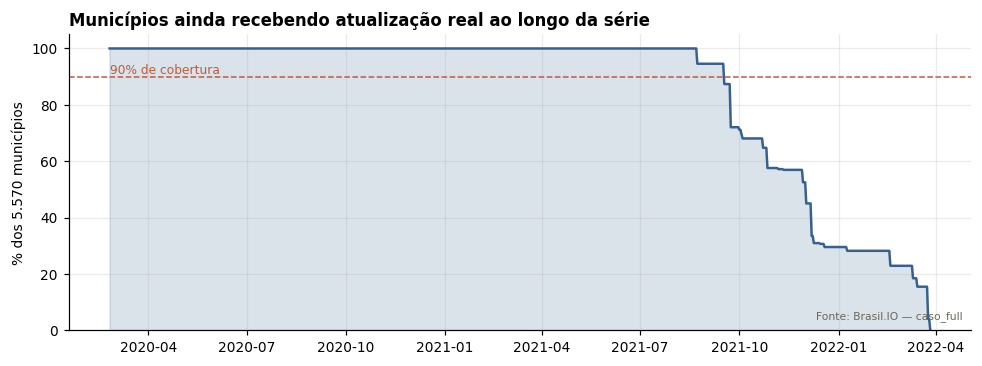

Última data com pelo menos 90% dos municípios atualizados: 16/09/2021


In [13]:
import matplotlib.pyplot as plt

CAMINHOS.figuras.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})

calendario = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
vivos = pd.Series([(congelamento >= d).sum() for d in calendario], index=calendario)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.fill_between(vivos.index, vivos / len(congelamento) * 100, color="#35608f", alpha=.18)
ax.plot(vivos.index, vivos / len(congelamento) * 100, color="#35608f", lw=1.6)
ax.axhline(90, ls="--", lw=1, color="#c25a3a")
ax.annotate("90% de cobertura", xy=(df["date"].min(), 91), fontsize=8, color="#c25a3a")
ax.set_ylim(0, 105)
ax.set_ylabel("% dos 5.570 municípios")
ax.set_title("Municípios ainda recebendo atualização real ao longo da série",
             loc="left", fontweight="bold")
ax.text(.99, .04, "Fonte: Brasil.IO — caso_full", transform=ax.transAxes,
        ha="right", fontsize=7, color="#6c665c")
fig.tight_layout()
fig.savefig(CAMINHOS.figuras / "cobertura_municipal.png", bbox_inches="tight")
plt.show()

limite = vivos[vivos / len(congelamento) >= .90].index.max()
print(f"Última data com pelo menos 90% dos municípios atualizados: {limite:%d/%m/%Y}")

diagnostico.append({
    "item": "Limite do dado municipal",
    "valor": f"{limite:%d/%m/%Y}",
    "interpretacao": ("A partir daí a cobertura municipal cai. Análises por município "
                      "devem ser recortadas até essa data; a série estadual segue completa"),
})

O resultado é direto: a cobertura municipal fica em 100% até meados de 2021, começa a cair
no terceiro trimestre e desaba no primeiro trimestre de 2022 — justamente durante a onda
Ômicron, quando os municípios capturam pouco mais de um quinto dos casos que as UFs
registram.

**Duas decisões de método saem daqui:**

1. **A análise por município é recortada** na última data com cobertura alta. Levá-la até
   março de 2022 faria a Ômicron parecer inexistente no interior do país — uma conclusão
   falsa produzida por uma falha de cobertura, não pela epidemia.
2. **A previsão usa a série estadual**, que permanece completa até o fim.

## 8. Quando cada UF começou a publicar

In [14]:
por_uf = (
    df[df["place_type"] == "state"]
    .groupby("state", observed=True)["date"]
    .agg(primeiro="min", ultimo="max", dias="count")
    .sort_values("primeiro")
)
por_uf["primeiro"] = por_uf["primeiro"].dt.strftime("%d/%m/%Y")
por_uf["ultimo"] = por_uf["ultimo"].dt.strftime("%d/%m/%Y")
por_uf

,primeiro,ultimo,dias
state,,,
SP,25/02/2020,27/03/2022,762
RJ,05/03/2020,27/03/2022,753
ES,05/03/2020,27/03/2022,753
BA,06/03/2020,27/03/2022,752
DF,07/03/2020,27/03/2022,751
AL,08/03/2020,27/03/2022,750
MG,08/03/2020,27/03/2022,750
RS,10/03/2020,27/03/2022,748
RN,12/03/2020,27/03/2022,746


## 9. Tabela de diagnóstico

Consolidação do que foi medido. Vai inteira para a seção de tratamento de dados do
Relatório Parcial.

In [15]:
tabela = pd.DataFrame(diagnostico)
destino = CAMINHOS.resultados / "qualidade_dados.csv"
tabela.to_csv(destino, index=False, encoding="utf-8")

print(f"Salvo em {destino.relative_to(CAMINHOS.raiz)}\n")
tabela

Salvo em resultados/qualidade_dados.csv



,item,valor,interpretacao
0,Período coberto,25/02/2020 a 27/03/2022,Da chegada da doença ao Brasil ao fim da onda ...
1,Total de registros,3.853.648,Uma linha por local e por dia
2,Municípios,5570,Praticamente a totalidade dos 5.570 municípios...
3,Unidades federativas,27,26 estados e o Distrito Federal
4,Linhas sem código IBGE,13.646,Todas do pseudo-município 'Importados/Indefini...
5,Duplicidades reais,0,Nenhuma: a chave local + data é única
6,Linhas com is_repeated,1.015.645,"Dias sem boletim novo, com repetição do acumul..."
7,new_confirmed negativos,38.638,Correções retroativas das secretarias; tratar ...
8,new_deaths negativos,6.261,Mesma origem
9,Lacuna entre níveis,6.298.850 casos (21.1%),Casos contados pela UF que nunca aparecem em n...


## Conclusões desta etapa

1. **A estrutura está íntegra.** Nenhuma linha malformada, nenhuma duplicidade real, e a
   chave local + data é única em todo o conjunto.
2. **O que parece sujeira, quase nunca é.** Os 26% de `is_repeated` são dias sem boletim, e
   verificamos que neles o incremento diário já vem exatamente zero — não exigem tratamento
   algum. Os valores negativos são correções retroativas. As linhas sem código IBGE são um
   pseudo-município documentado, presente em 19 UFs.
3. **O problema real é de cobertura, não de sujeira.** As séries municipais congelam em
   datas diferentes, e a partir do terceiro trimestre de 2021 a cobertura despenca. Seis
   milhões de casos — 21% do total — existem na série estadual e em nenhum município.
4. **Isso define o desenho do trabalho.** Análise por município recortada até a última data
   com cobertura alta; previsão sobre a série estadual, que vai completa até o fim.
5. **Comparação exige normalização.** Números absolutos entre São Paulo e Acre medem
   população, não epidemia. Daqui em diante, tudo por 100 mil habitantes.

**Próximo passo:** `02_eda.ipynb` — análise exploratória das variáveis.